# Probability for Deep Learning — Hands-On

**What you'll do here:**

1. Turn logits into probabilities using **sigmoid** and **softmax**
2. Compute **cross-entropy loss**
3. Use a **Gaussian distribution** to initialize weights

Same notation as the videos.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(20)

## 1. The Big Idea

A model doesn't say *"this is a cat"*. It says *"92% cat, 8% dog"*.

But the raw output of a network — a **logit** — can be any real number. We need a function to turn logits into valid probabilities (between 0 and 1, summing to 1).

## 2. Sigmoid — Binary Classification

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Maps any real number into `(0, 1)`. From the video: `σ(2.0) ≈ 0.88`.

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print("σ(2.0)  =", round(sigmoid(2.0), 4))
print("σ(0.0)  =", round(sigmoid(0.0), 4))    # always 0.5
print("σ(-2.0) =", round(sigmoid(-2.0), 4))
print("σ(5.0)  =", round(sigmoid(5.0), 4))    # near 1
print("σ(-5.0) =", round(sigmoid(-5.0), 4))   # near 0

σ(2.0)  = 0.8808
σ(0.0)  = 0.5
σ(-2.0) = 0.1192
σ(5.0)  = 0.9933
σ(-5.0) = 0.0067


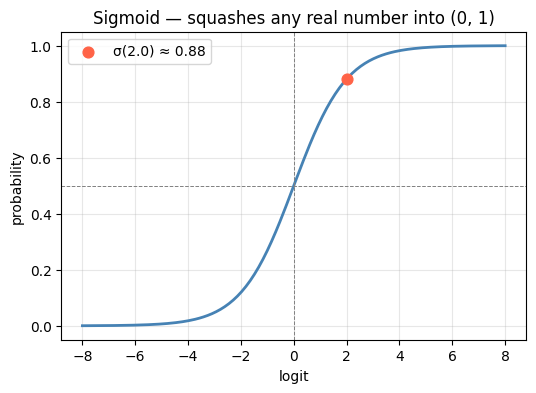

In [8]:
x = np.linspace(-8, 8, 200)

plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid(x), color='steelblue', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0,   color='gray', linestyle='--', linewidth=0.7)
plt.scatter([2.0], [sigmoid(2.0)], color='tomato', s=60, zorder=3, label="σ(2.0) ≈ 0.88")
plt.title("Sigmoid — squashes any real number into (0, 1)")
plt.xlabel("logit"); plt.ylabel("probability")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Use:** binary classification. One logit → one probability.

## 3. Softmax — Multi-Class Classification

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

Takes a *vector* of logits, returns a *vector* of probabilities that sum to 1.

From the video: `[2.0, 1.0, 0.1]` → `[0.66, 0.24, 0.10]`.

In [9]:
def softmax(logits):
    # Subtract max for numerical stability
    shifted = logits - np.max(logits)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores)

logits = np.array([2.0, 1.0, 0.1])
probs  = softmax(logits)

print("logits:", logits)
print("probs :", np.round(probs, 2))
print("sum   :", round(probs.sum(), 4))

logits: [2.  1.  0.1]
probs : [0.66 0.24 0.1 ]
sum   : 1.0


A more concrete example — an image classifier with 3 classes:

In [10]:
classes = ['cat', 'dog', 'rabbit']
logits  = np.array([2.7, 1.3, -0.5])
probs   = softmax(logits)

print(f"{'class':<8}{'logit':>8}{'prob':>10}")
print("-" * 26)
for c, lo, p in zip(classes, logits, probs):
    print(f"{c:<8}{lo:>8.2f}{p:>10.4f}")

print(f"\nPrediction: {classes[np.argmax(probs)]}")

class      logit      prob
--------------------------
cat         2.70    0.7768
dog         1.30    0.1916
rabbit     -0.50    0.0317

Prediction: cat


Softmax *exaggerates* differences — small gaps in logits become bigger gaps in probabilities. That's the exponential at work.

## 4. Cross-Entropy Loss

$$L = -\sum_i y_i \log(\hat{y}_i)$$

**It punishes confident-wrong answers the hardest.** Same table from the video — true label is *cat*:

| Predicted prob for cat | Expected penalty |
|------------------------|------------------|
| 0.85                   | Low              |
| 0.45                   | Medium           |
| 0.05                   | High             |

In [11]:
def cross_entropy(y_true, y_pred, eps=1e-12):
    # Clip to avoid log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.sum(y_true * np.log(y_pred))

# True label: cat -> one-hot [1, 0]
y_true = np.array([1, 0])

predictions = [
    ("confident correct", np.array([0.85, 0.15])),
    ("unsure         ",   np.array([0.45, 0.55])),
    ("confident wrong",   np.array([0.05, 0.95])),
]

print(f"{'case':<20}{'p(cat)':>10}{'loss':>10}")
print("-" * 40)
for name, y_pred in predictions:
    loss = cross_entropy(y_true, y_pred)
    print(f"{name:<20}{y_pred[0]:>10.2f}{loss:>10.4f}")

case                    p(cat)      loss
----------------------------------------
confident correct         0.85    0.1625
unsure                    0.45    0.7985
confident wrong           0.05    2.9957


Confident-wrong gets a loss roughly **20× higher** than confident-correct. Let's see this as a curve:

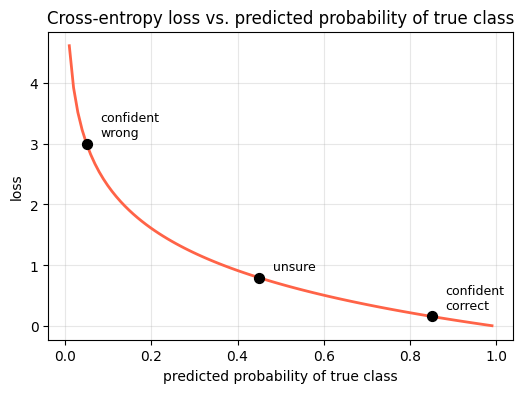

In [12]:
p_correct = np.linspace(0.01, 0.99, 100)
loss_curve = -np.log(p_correct)

plt.figure(figsize=(6, 4))
plt.plot(p_correct, loss_curve, color='tomato', linewidth=2)
plt.scatter([0.85, 0.45, 0.05], [-np.log(0.85), -np.log(0.45), -np.log(0.05)],
            color='black', zorder=3, s=50)
for px, label in [(0.85, "confident\ncorrect"), (0.45, "unsure"), (0.05, "confident\nwrong")]:
    plt.annotate(label, (px, -np.log(px)), textcoords="offset points",
                 xytext=(10, 5), fontsize=9)
plt.title("Cross-entropy loss vs. predicted probability of true class")
plt.xlabel("predicted probability of true class"); plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.show()

The curve **shoots up** as the prediction for the correct class drops — telling the network *"don't be confidently wrong."*

### 4.1 Full Pipeline — Logits → Softmax → Cross-Entropy

This is what happens for every training example, every step.

In [13]:
# 3-class problem. True label: cat
y_true = np.array([1, 0, 0])

# Network output (logits)
logits = np.array([2.7, 1.3, -0.5])

# Step 1: logits -> probabilities
probs = softmax(logits)

# Step 2: probabilities vs true label -> loss
loss = cross_entropy(y_true, probs)

print("logits        :", logits)
print("probabilities :", np.round(probs, 4))
print("true label    :", y_true)
print("loss          :", round(loss, 4))

logits        : [ 2.7  1.3 -0.5]
probabilities : [0.7768 0.1916 0.0317]
true label    : [1 0 0]
loss          : 0.2526


This loss is the single number gradient descent tries to minimize.

## 5. Gaussian Distribution — Weight Initialization

A bell curve — most values near the center (`μ`), fewer at the edges. Spread controlled by `σ`.

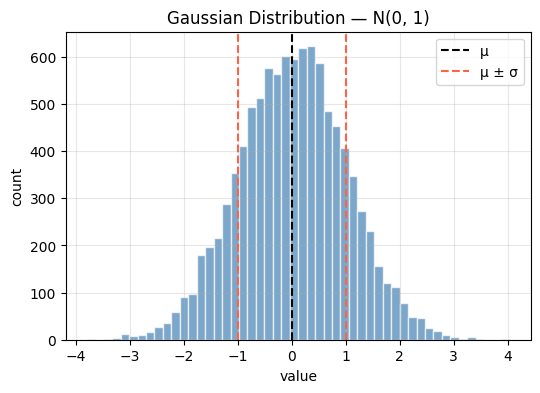

In [14]:
mu, sigma = 0.0, 1.0
samples = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.figure(figsize=(6, 4))
plt.hist(samples, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(mu,         color='black',  linestyle='--', label='μ')
plt.axvline(mu - sigma, color='tomato', linestyle='--', label='μ ± σ')
plt.axvline(mu + sigma, color='tomato', linestyle='--')
plt.title("Gaussian Distribution — N(0, 1)")
plt.xlabel("value"); plt.ylabel("count")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Now initialize a weight matrix the way real networks do — small random values from a Gaussian:

In [15]:
# Weight matrix: 3 output neurons, 5 inputs each. Small std (0.01) keeps weights tiny
W = np.random.normal(loc=0.0, scale=0.01, size=(3, 5))

print("W shape:", W.shape)
print("W:\n", np.round(W, 5))
print("\nmean:", round(W.mean(), 6))
print("std :", round(W.std(), 6))

W shape: (3, 5)
W:
 [[-0.00287 -0.00076  0.00167 -0.00574  0.00946]
 [-0.00298  0.00159 -0.00413 -0.00544 -0.00566]
 [-0.00229 -0.005   -0.02048 -0.01494  0.01295]]

mean: -0.002975
std : 0.007883


### 5.1 Why Not Zero?

If every weight starts at zero, every neuron computes the same thing — and gets the same gradient. They can never specialize.

In [16]:
x = np.array([0.5, -0.2, 0.8, 0.1, -0.4])

# Strategy 1: all zeros
W_zero  = np.zeros((4, 5))
out_zero = W_zero @ x

# Strategy 2: Gaussian
W_gauss = np.random.normal(0, 0.5, size=(4, 5))
out_gauss = W_gauss @ x

print("Zero init     :", out_zero)
print("  -> all 4 neurons identical -> no learning\n")
print("Gaussian init :", np.round(out_gauss, 4))
print("  -> all 4 neurons different -> can specialize")

Zero init     : [0. 0. 0. 0.]
  -> all 4 neurons identical -> no learning

Gaussian init : [-0.5143 -0.4069  0.263   0.3748]
  -> all 4 neurons different -> can specialize


Gaussian init breaks the symmetry — that's why every framework defaults to it.

## 6. Recap

| Question                       | Tool             |
|--------------------------------|------------------|
| How sure am I? (2 classes)     | Sigmoid          |
| How sure am I? (>2 classes)    | Softmax          |
| How wrong was I?               | Cross-entropy    |
| How do I start?                | Gaussian init    |

Combined with linear algebra and calculus, you now have **all three math pillars** of deep learning.